In [131]:
import tensorflow as tf
print(tf.__version__)


2.17.1


In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Flatten, Dense, Concatenate, Dropout
from tensorflow.keras.optimizers import Adam

In [133]:
# Załaduj dane
url_ratings = "https://files.grouplens.org/datasets/movielens/ml-100k/u.data"
url_movies = "https://files.grouplens.org/datasets/movielens/ml-100k/u.item"
columns_ratings = ["user_id", "item_id", "rating", "timestamp"]
columns_movies = ["item_id", "title", "release_date", "video_release_date", "IMDb_URL", "unknown", "Action", "Adventure", "Animation", "Children's", "Comedy", "Crime", "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror", "Musical", "Mystery", "Romance", "Sci-Fi", "Thriller", "War", "Western"]
ratings = pd.read_csv(url_ratings, sep='\t', names=columns_ratings, engine='python')
movies = pd.read_csv(url_movies, sep='|', names=columns_movies, encoding='latin-1', engine='python')

In [134]:
# Wyświetlenie przykładowych danych
print("\nPrzykładowe dane z tabeli ocen (ratings):")
print(ratings.head())

print("\nPrzykładowe dane z tabeli filmów (movies):")
print(movies.head())


Przykładowe dane z tabeli ocen (ratings):
   user_id  item_id  rating  timestamp
0      196      242       3  881250949
1      186      302       3  891717742
2       22      377       1  878887116
3      244       51       2  880606923
4      166      346       1  886397596

Przykładowe dane z tabeli filmów (movies):
   item_id              title release_date  video_release_date  \
0        1   Toy Story (1995)  01-Jan-1995                 NaN   
1        2   GoldenEye (1995)  01-Jan-1995                 NaN   
2        3  Four Rooms (1995)  01-Jan-1995                 NaN   
3        4  Get Shorty (1995)  01-Jan-1995                 NaN   
4        5     Copycat (1995)  01-Jan-1995                 NaN   

                                            IMDb_URL  unknown  Action  \
0  http://us.imdb.com/M/title-exact?Toy%20Story%2...        0       0   
1  http://us.imdb.com/M/title-exact?GoldenEye%20(...        0       1   
2  http://us.imdb.com/M/title-exact?Four%20Rooms%...        0  

In [135]:
# Podstawowa analiza danych
print("Podstawowe informacje o danych:")
print(ratings.info())
print("\nPrzykładowe wiersze:")
print(ratings.head())


Podstawowe informacje o danych:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   item_id    100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB
None

Przykładowe wiersze:
   user_id  item_id  rating  timestamp
0      196      242       3  881250949
1      186      302       3  891717742
2       22      377       1  878887116
3      244       51       2  880606923
4      166      346       1  886397596


In [136]:
# Statystyki podstawowe
print("\nUnikalni użytkownicy:", ratings['user_id'].nunique())
print("Unikalne filmy:", ratings['item_id'].nunique())


Unikalni użytkownicy: 943
Unikalne filmy: 1682


In [137]:
# Podział danych na zbiór treningowy i testowy
train, test = train_test_split(ratings, test_size=0.2, random_state=42)

# Maksymalne wartości ID użytkownika i filmu
n_users = ratings['user_id'].max()
n_items = ratings['item_id'].max()

In [138]:
# Budowa sieci neuronowej
# Warstwy wejściowe
user_input = Input(shape=(1,), name='user_input')
item_input = Input(shape=(1,), name='item_input')

# Embeddingi
user_embedding = Embedding(input_dim=n_users + 1, output_dim=50, name='user_embedding')(user_input)
item_embedding = Embedding(input_dim=n_items + 1, output_dim=50, name='item_embedding')(item_input)

# Spłaszczenie embeddingów
user_vector = Flatten(name='user_vector')(user_embedding)
item_vector = Flatten(name='item_vector')(item_embedding)

# Połączenie cech użytkownika i filmu
merged = Concatenate()([user_vector, item_vector])

In [139]:
# Warstwy ukryte
hidden = Dense(128, activation='relu')(merged)
hidden = Dropout(0.3)(hidden)
hidden = Dense(64, activation='relu')(hidden)


# Wyjście
output = Dense(1, activation='linear', name='output')(hidden)

In [140]:
# Model
model = Model(inputs=[user_input, item_input], outputs=output)
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['mae'])

print("Model zbudowany:")
model.summary()

Model zbudowany:


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ user_input (InputLayer)   │ (None, 1)              │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ item_input (InputLayer)   │ (None, 1)              │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ user_embedding            │ (None, 1, 50)          │         47,200 │ user_input[0][0]       │
│ (Embedding)               │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ item_embedding            │ (None, 1, 50)          │         84,150 │ item_input[0][0]       │
│ (Embedding)               │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ user_vector (Flatten)     │ (None, 50)             │              0 │ user_embedding[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ item_vector (Flatten)     │ (None, 50)             │              0 │ item_embedding[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_5             │ (None, 100)            │              0 │ user_vector[0][0],     │
│ (Concatenate)             │                        │                │ item_vector[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_12 (Dense)          │ (None, 128)            │         12,928 │ concatenate_5[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_6 (Dropout)       │ (None, 128)            │              0 │ dense_12[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_13 (Dense)          │ (None, 64)             │          8,256 │ dropout_6[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ output (Dense)            │ (None, 1)              │             65 │ dense_13[0][0]         │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 152,599 (596.09 KB)

 Trainable params: 152,599 (596.09 KB)

 Non-trainable params: 0 (0.00 B)

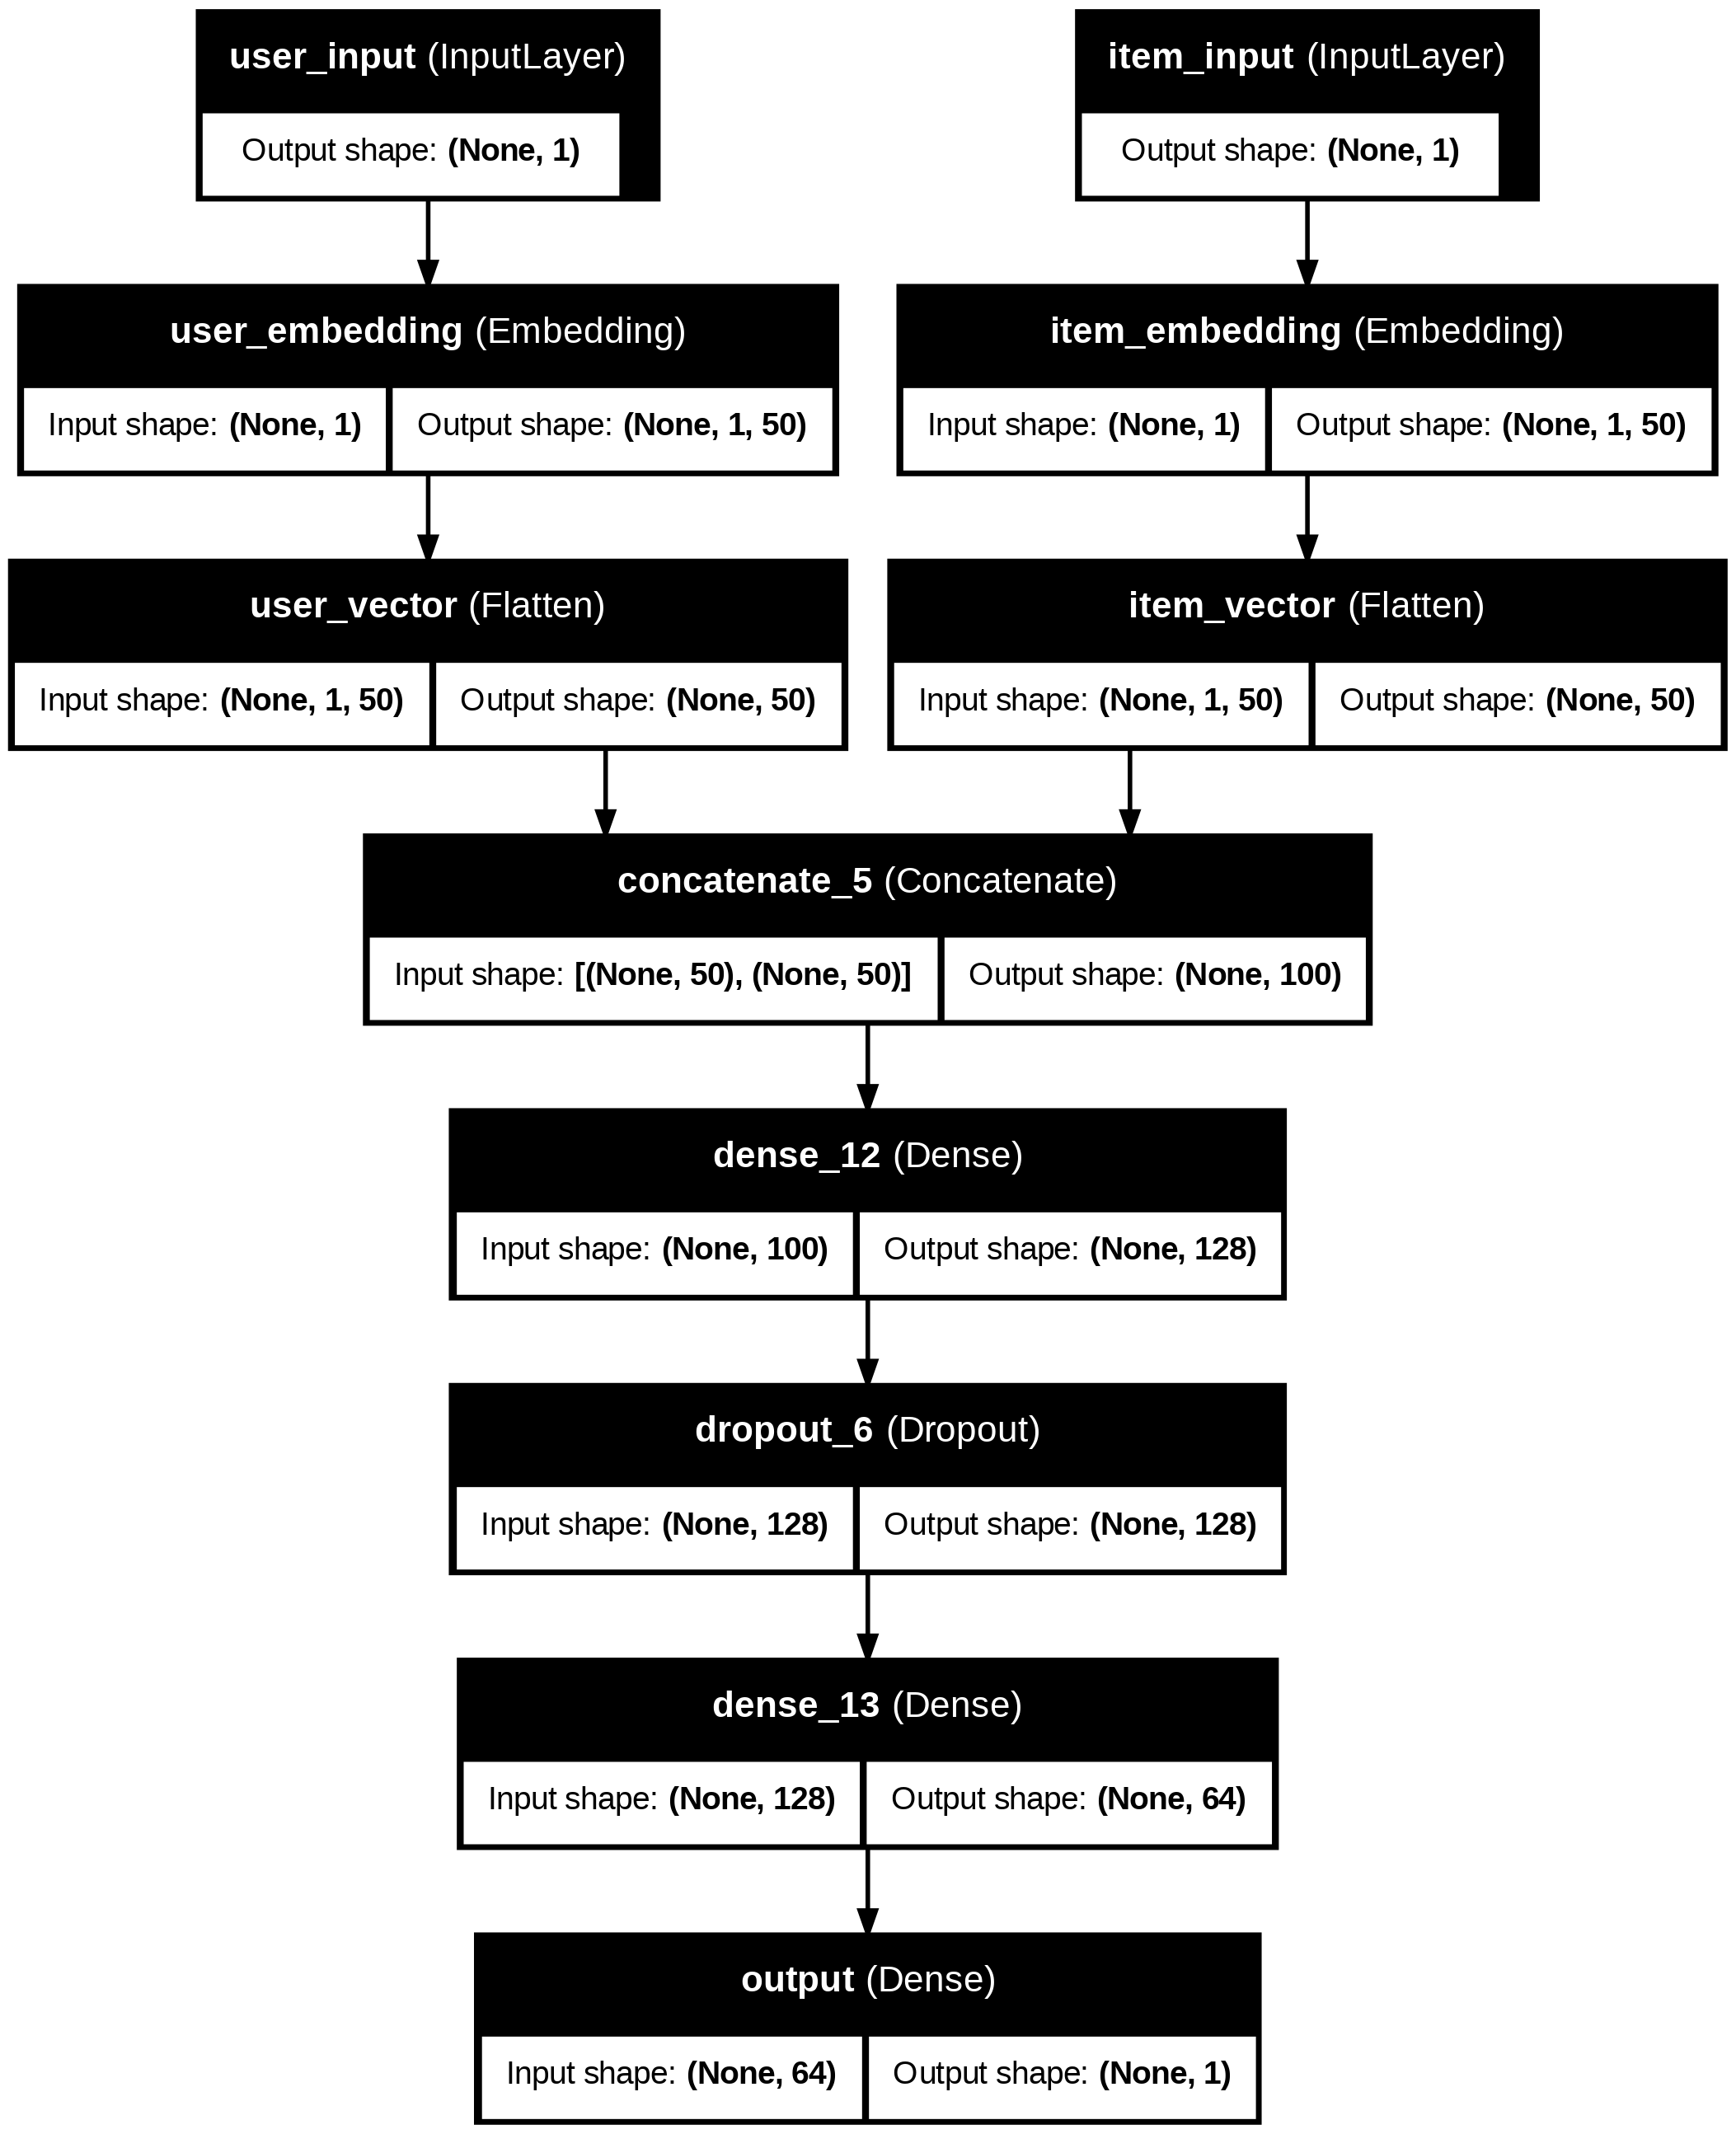

In [141]:
from tensorflow.keras.utils import plot_model

# Zapisz schemat modelu do pliku PNG
plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)


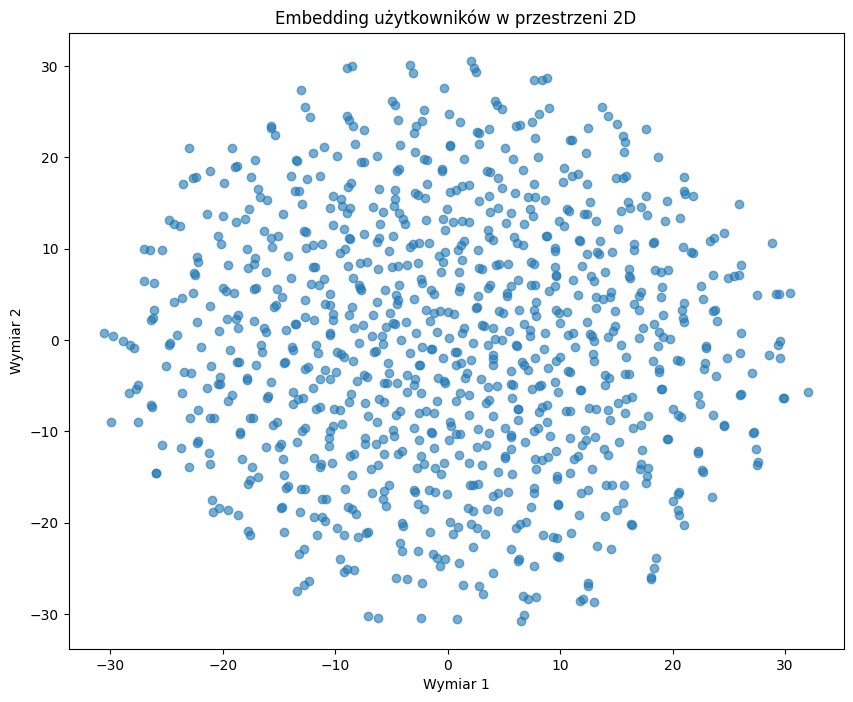

In [142]:
# Pobierz wagi embeddingów użytkowników
user_embedding_weights = model.get_layer('user_embedding').get_weights()[0]

# Redukcja wymiarów (np. do 2D)
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
user_embedding_2d = tsne.fit_transform(user_embedding_weights)

# Wykres
plt.figure(figsize=(10, 8))
plt.scatter(user_embedding_2d[:, 0], user_embedding_2d[:, 1], alpha=0.6)
plt.title('Embedding użytkowników w przestrzeni 2D')
plt.xlabel('Wymiar 1')
plt.ylabel('Wymiar 2')
plt.show()


In [143]:
# Przygotowanie danych do trenowania
x_train = [train['user_id'].values, train['item_id'].values]
y_train = train['rating'].values
x_test = [test['user_id'].values, test['item_id'].values]
y_test = test['rating'].values

In [144]:
# Trenowanie modelu
history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_data=(x_test, y_test), verbose=1)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 2.3946 - mae: 1.1411 - val_loss: 0.9154 - val_mae: 0.7537
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9313 - mae: 0.7648 - val_loss: 0.8925 - val_mae: 0.7529
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.8849 - mae: 0.7463 - val_loss: 0.8836 - val_mae: 0.7509
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.8467 - mae: 0.7264 - val_loss: 0.8666 - val_mae: 0.7319
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.8161 - mae: 0.7122 - val_loss: 0.8731 - val_mae: 0.7332
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.8006 - mae: 0.7063 - val_loss: 0.8660 - val_mae: 0.7302
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.7669 - mae: 0.6888 - val_loss: 0.8598 - val_mae: 0.7323
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7357 - mae: 0.6754 - val_loss: 0.8716 - val_mae: 0.7317
Epoch 9/10
1250/1250 ━━━━━━━━━━━━━━━━━━━

In [145]:
# Wykresy uczenia
plt.figure(figsize=(20, 6))

<Figure size 2000x600 with 0 Axes>

<Figure size 2000x600 with 0 Axes>

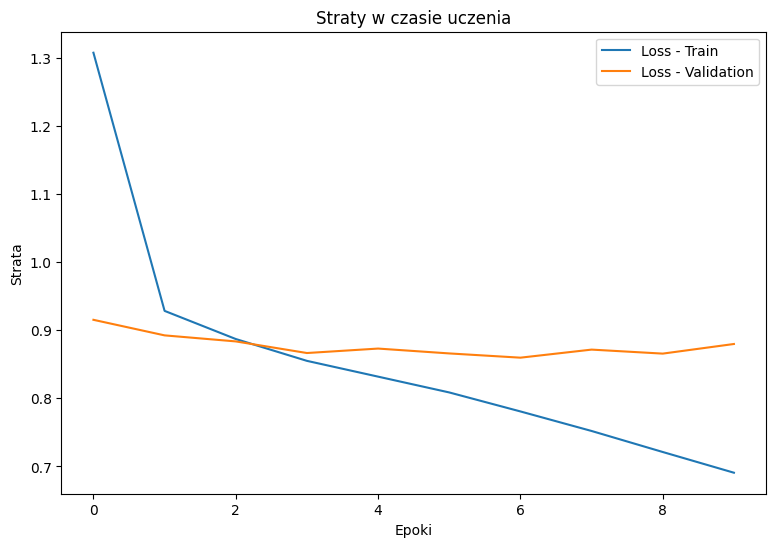

In [154]:
# Wykres strat
plt.figure(figsize=(20, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Loss - Train')
plt.plot(history.history['val_loss'], label='Loss - Validation')
plt.title('Straty w czasie uczenia')
plt.xlabel('Epoki')
plt.ylabel('Strata')
plt.legend()


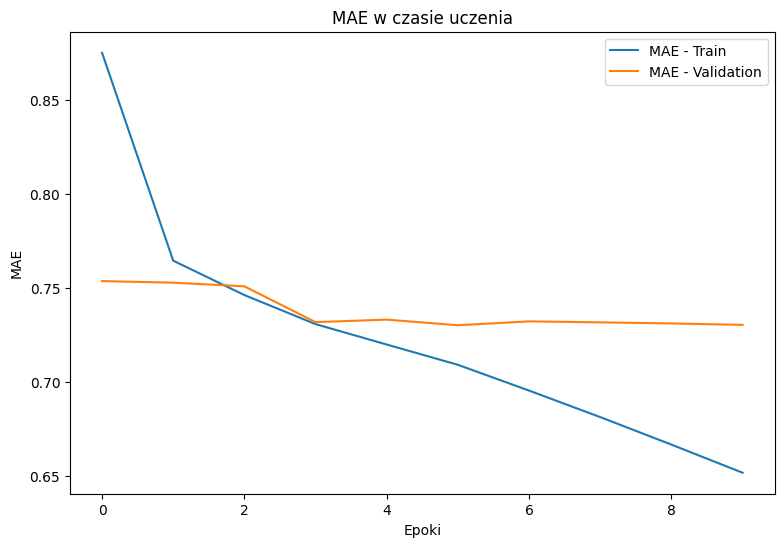

In [155]:
# Wykres MAE
plt.figure(figsize=(20, 6))
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='MAE - Train')
plt.plot(history.history['val_mae'], label='MAE - Validation')
plt.title('MAE w czasie uczenia')
plt.xlabel('Epoki')
plt.ylabel('MAE')
plt.legend()

plt.show()

2500/2500 ━━━━━━━━━━━━━━━━━━━━ 2s 955us/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 937us/step


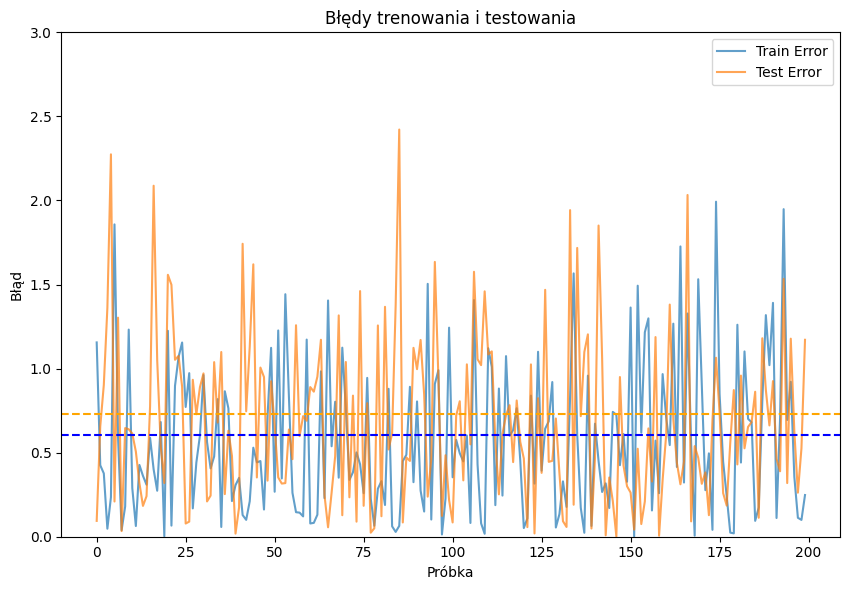

In [148]:
# Wykres błędów trenowania i testowania
train_predictions = model.predict(x_train).flatten()
test_predictions = model.predict(x_test).flatten()
train_error = np.abs(train_predictions - y_train)
test_error = np.abs(test_predictions - y_test)

plt.figure(figsize=(25, 6))
plt.subplot(1, 3, 3)
plt.plot(train_error[:200], label='Train Error', alpha=0.7)
plt.plot(test_error[:200], label='Test Error', alpha=0.7)
plt.ylim(0, 3)
plt.title('Błędy trenowania i testowania')
plt.xlabel('Próbka')
plt.ylabel('Błąd')
plt.legend()

plt.axhline(y=np.mean(train_error), color='blue', linestyle='--', label='Średni Train Error')
plt.axhline(y=np.mean(test_error), color='orange', linestyle='--', label='Średni Test Error')


plt.tight_layout()
plt.show()

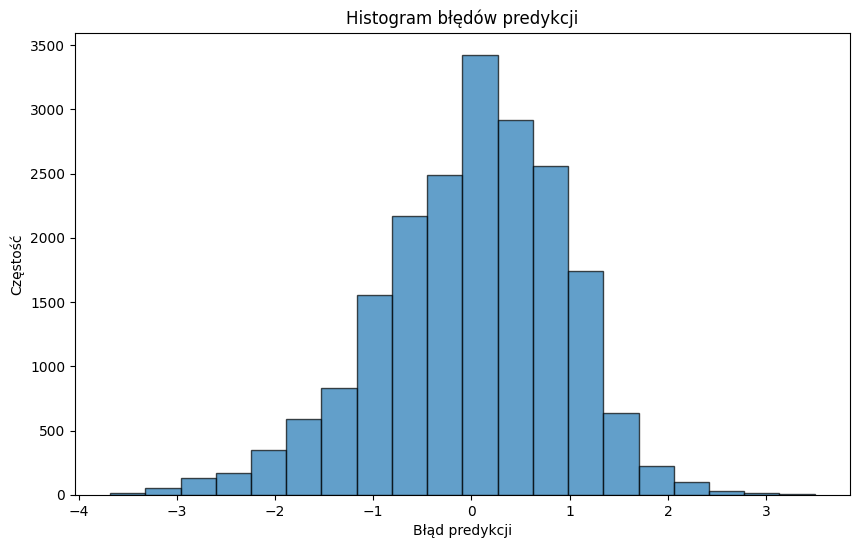

In [149]:
# Histogram błędów predykcji
errors = comparison['Actual'] - comparison['Predicted']
plt.figure(figsize=(10, 6))
plt.hist(errors, bins=20, edgecolor='k', alpha=0.7)
plt.title('Histogram błędów predykcji')
plt.xlabel('Błąd predykcji')
plt.ylabel('Częstość')
plt.show()


In [150]:
# Ocena modelu na zbiorze testowym
loss, mae = model.evaluate(x_test, y_test, verbose=0)
print(f"\nOstateczna strata (Loss): {loss:.4f}")
print(f"Średni błąd absolutny (MAE): {mae:.4f}")


Ostateczna strata (Loss): 0.8799
Średni błąd absolutny (MAE): 0.7304


In [151]:
# Wizualizacja predykcji
predictions = model.predict(x_test)
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': predictions.flatten()})
comparison_sample = comparison.sample(20)
# Tabela porównawcza
print("\nPrzykładowe porównanie rzeczywistych i przewidywanych ocen:")
print(comparison_sample)

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

Przykładowe porównanie rzeczywistych i przewidywanych ocen:
       Actual  Predicted
18961       5   4.135961
4410        4   3.727325
19909       4   4.530273
2515        3   3.810834
16151       4   3.353012
395         4   3.654783
1737        3   2.903237
16727       3   2.807914
10158       4   3.871989
14037       4   4.353375
11300       5   4.741185
5369        4   4.084965
12247       3   3.591785
3322        2   2.258145
18943       4   3.400347
824         2   2.273896
19511       1   3.090523
510         5   4.039547
7265        3   3.476036
3930        3   4.181019


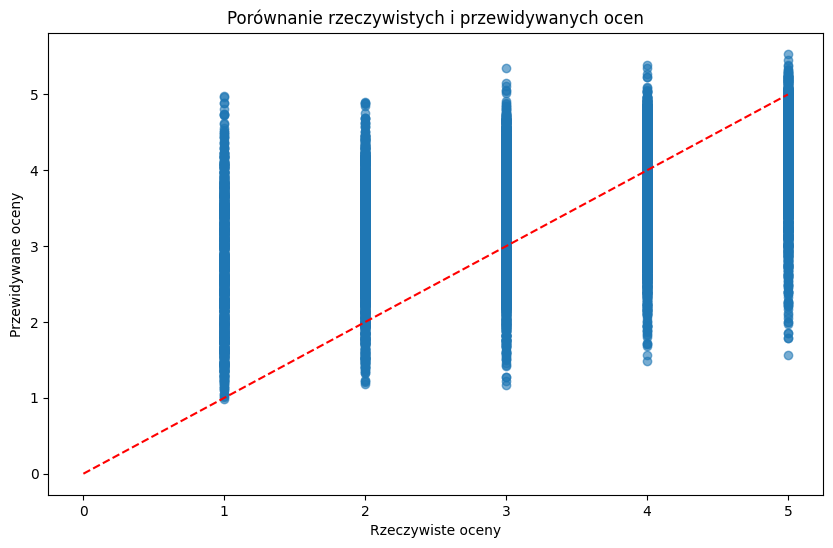

In [152]:
# Wykres porównawczy
plt.figure(figsize=(10, 6))
plt.scatter(comparison['Actual'], comparison['Predicted'], alpha=0.6)
plt.plot([0, 5], [0, 5], '--r', label='Ideal Line')
plt.title('Porównanie rzeczywistych i przewidywanych ocen')
plt.xlabel('Rzeczywiste oceny')
plt.ylabel('Przewidywane oceny')
plt.show()


In [153]:
# Przewidywanie filmu dla konkretnego użytkownika
user_id_to_predict = 1  # Przykładowy użytkownik
all_items = np.arange(1, n_items + 1)  # Wszystkie ID filmów
user_ids = np.full(shape=all_items.shape, fill_value=user_id_to_predict)  # Powiel ID użytkownika

predicted_ratings = model.predict([user_ids, all_items]).flatten()
recommendations = pd.DataFrame({
    'item_id': all_items,
    'predicted_rating': predicted_ratings
}).sort_values(by='predicted_rating', ascending=False).head(10)

# Dołączenie tytułów filmów
recommendations = recommendations.merge(movies[['item_id', 'title']], on='item_id', how='left')

print("\nRekomendowane filmy dla użytkownika:")
print(recommendations)

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

Rekomendowane filmy dla użytkownika:
   item_id  predicted_rating                         title
0     1500          5.526548     Santa with Muscles (1996)
1     1449          5.506203        Pather Panchali (1955)
2     1398          5.475004                   Anna (1996)
3      867          5.243047  Whole Wide World, The (1996)
4     1645          5.140986       Butcher Boy, The (1998)
5     1612          5.120582       Leading Man, The (1996)
6      408          5.111560         Close Shave, A (1995)
7       50          5.109578              Star Wars (1977)
8     1642          5.089578      Some Mother's Son (1996)
9     1306          5.054893         Delta of Venus (1994)
